In [13]:
# Importar librerías necesarias

# Librerías estándar de Python
import json

# Librerías de terceros
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LogisticRegression

# ==============================
# CONFIGURACIÓN DE DISPOSITIVO
# ==============================

# Selecciona GPU si está disponible, de lo contrario usa CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Muestra el dispositivo que se está utilizando
print(f"Usando: {device}")

Usando: cpu


In [14]:
#Cargar datos y definir target

df = pd.read_csv("data_loan_clean.csv", low_memory=False)
cols = json.load(open("esquema_modelo.json"))["columnas_modelo"]
cols = [c for c in cols if c not in ["loan_status", "default", "verification_status_joint"]]

status_map = {
    "Fully Paid":                                          0,
    "Does not meet the credit policy. Status:Fully Paid":  0,
    "Charged Off":                                         1,
    "Default":                                             1,
    "Late (31-120 days)":                                  1,
    "Does not meet the credit policy. Status:Charged Off": 1,
}

df = df[df["loan_status"].isin(status_map)].copy()
df["default"] = df["loan_status"].map(status_map)

print(f"Filas para modelo: {len(df):,}")
print(df["default"].value_counts(normalize=True).mul(100).round(2))

Filas para modelo: 268,530
default
0    78.1
1    21.9
Name: proportion, dtype: float64


In [15]:
# ── 2. Separar X e y ───────────────────────────────────────────────
X = df[cols]
y = df["default"].values

print(f"\nShape X: {X.shape}")
print(f"Shape y: {y.shape}")


Shape X: (268530, 73)
Shape y: (268530,)


In [16]:
# ── 3. Train / Test split ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")
print(f"Default en train: {y_train.mean()*100:.2f}%")
print(f"Default en test:  {y_test.mean()*100:.2f}%")



Train: (214824, 73) | Test: (53706, 73)
Default en train: 21.90%
Default en test:  21.90%


In [17]:
# ── 4. Imputar NaN con mediana ─────────────────────────────────────
imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=cols
)
X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=cols
)

print(f"\nNaN restantes en X_train: {X_train.isnull().sum().sum()}")



NaN restantes en X_train: 0


In [18]:
# ── 5. Escalar variables ───────────────────────────────────────────
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [19]:
# ── 6. Entrenar modelo ─────────────────────────────────────────────
modelo = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

modelo.fit(X_train_scaled, y_train)
print("\nModelo entrenado ✓")

c:\Users\dfgar\Documents\GitHub\RNA-Trabajo-2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Modelo entrenado ✓


In [20]:
# ── 7. Predicciones ────────────────────────────────────────────────
y_pred = modelo.predict(X_test_scaled)
y_prob = modelo.predict_proba(X_test_scaled)[:, 1]

In [21]:
# ── 8. Métricas ────────────────────────────────────────────────────
print("\n── Classification Report ──────────────────────────────────")
print(classification_report(y_test, y_pred,
                             target_names=["No Default (0)", "Default (1)"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")


── Classification Report ──────────────────────────────────
                precision    recall  f1-score   support

No Default (0)       0.86      0.66      0.75     41942
   Default (1)       0.34      0.63      0.44     11764

      accuracy                           0.65     53706
     macro avg       0.60      0.64      0.59     53706
  weighted avg       0.75      0.65      0.68     53706

ROC-AUC: 0.6950


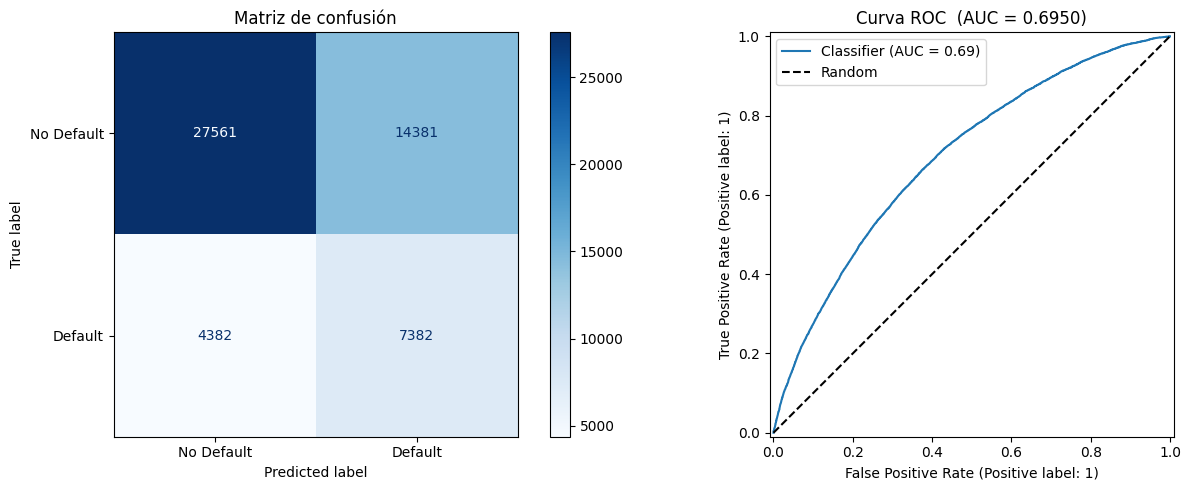

In [22]:
# ── 9. Visualizaciones ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["No Default", "Default"],
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Matriz de confusión")

# Curva ROC
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title(f"Curva ROC  (AUC = {roc_auc_score(y_test, y_prob):.4f})")
axes[1].plot([0, 1], [0, 1], "k--", label="Random")
axes[1].legend()

plt.tight_layout()
plt.show()


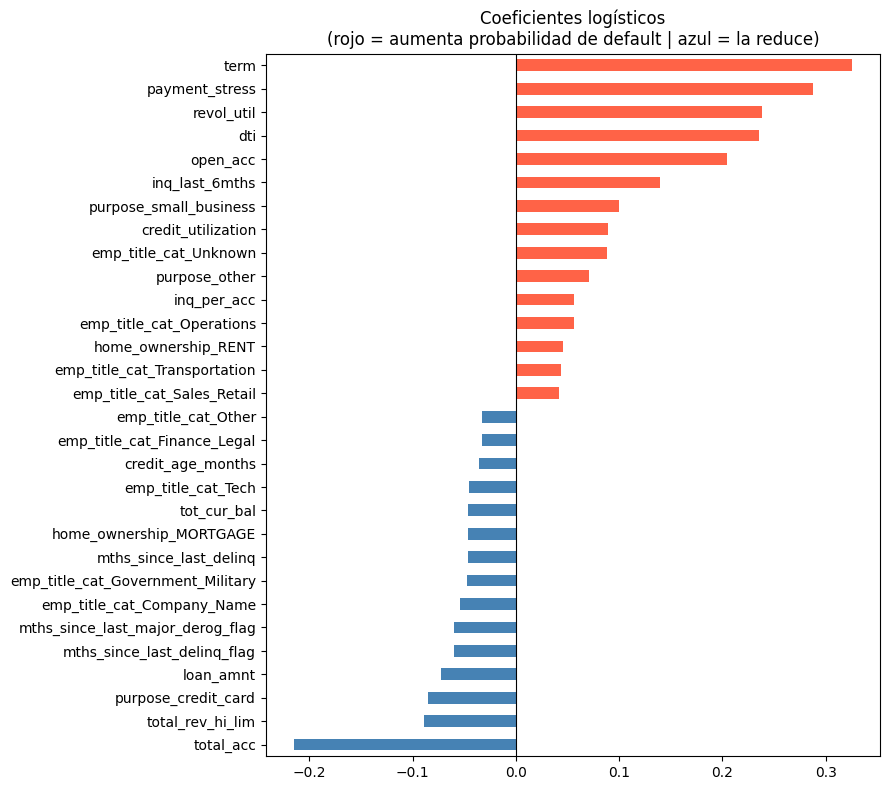


Top 10 variables que MÁS aumentan default:
term                      0.325518
payment_stress            0.287708
revol_util                0.238033
dti                       0.235090
open_acc                  0.204082
inq_last_6mths            0.140061
purpose_small_business    0.099603
credit_utilization        0.088907
emp_title_cat_Unknown     0.088677
purpose_other             0.070894

Top 10 variables que MÁS reducen default:
home_ownership_MORTGAGE             -0.046230
mths_since_last_delinq              -0.046352
emp_title_cat_Government_Military   -0.046950
emp_title_cat_Company_Name          -0.053886
mths_since_last_major_derog_flag    -0.060063
mths_since_last_delinq_flag         -0.060168
loan_amnt                           -0.071942
purpose_credit_card                 -0.085296
total_rev_hi_lim                    -0.089331
total_acc                           -0.214948


In [23]:
# ── 10. Coeficientes ───────────────────────────────────────────────
coeficientes = pd.Series(
    modelo.coef_[0],
    index=cols
).sort_values(ascending=False)

# Top 15 positivos y negativos
top_n = 15
top_coefs = pd.concat([
    coeficientes.head(top_n),
    coeficientes.tail(top_n)
]).sort_values()

colores = ["steelblue" if v < 0 else "tomato" for v in top_coefs]

top_coefs.plot(kind="barh", figsize=(9, 8), color=colores)
plt.title("Coeficientes logísticos\n"
          "(rojo = aumenta probabilidad de default | "
          "azul = la reduce)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nTop 10 variables que MÁS aumentan default:")
print(coeficientes.head(10).to_string())

print("\nTop 10 variables que MÁS reducen default:")
print(coeficientes.tail(10).to_string())
